### This notebook performs in-silico mutagenesis (ISM) on a gene of interest under a selected condition to identify putative regulatory regions and transcription factor (TF) drivers of gene expression.

> **Note:** This notebook uses the Araport11 genome annotation.

> **Note:** The analyses generated by this notebook may not be equally reliable for all genes or experimental conditions. To help assess result quality, we report a confidence measure for each gene based on the Pearson correlation coefficient and Spearman correlation coefficient between observed gene expression and model predictions. Higher correlation values indicate better agreement and, consequently, greater confidence in the inferred regulatory insights.

### What this does:
* Mutates each nucleotide in a gene TSS-centered sequence
* Measures impact on predicted expression
* Identifies important positions
* Links mutations to TF binding and ChIP-seq evidence
* Generates visualization tracks

### Action Required: Section 3 (User Input):
* GENE_NAME: The locus ID (e.g., AT2G01980).
* EXPERIMENT_ID: The unique identifier for the expression experiment


# 1. Setup & Imports, Environment & Paths

In [1]:
import pandas as pd
from src.utils import hot_encode_sequence, create_path
import torch
from fastprogress import progress_bar
from src.config import ExpressionConfig
from src.utils import read_json, get_device
from src.DeepPlant_expression import build_model
import numpy as np
from src.ISM_utils import *
import os
from dotenv import load_dotenv
from scipy.stats import pearsonr,spearmanr
import seaborn as sns
sns.set_theme(style='white')
import h5py

# 1. Load the variables from the .env file
load_dotenv()

# 2. Grab the global path
deep_plant_path = os.getenv("DEEPPLANTPATH")

if not deep_plant_path:
    raise ValueError("DEEPPLANTPATH is missing! Run 'python3 setup_env.py' in the root DeepPlant directory")

load_dotenv()

deep_plant_path = os.getenv("DEEPPLANTPATH")

if not deep_plant_path:
    raise ValueError(
        "DEEPPLANTPATH is not set.\n"
        "Fix:\n"
        "  export DEEPPLANTPATH=/path/to/DeepPlant"
    )

# Paths
json_path = os.path.join(deep_plant_path, "config/config_AT_expression.json")
model_path = os.path.join(deep_plant_path, "models/model_AT_GEP.pt")

gene_df_path = os.path.join(deep_plant_path, "data/arabidopsis/GEP/gene_list.txt")
gex_metadata_path = os.path.join(deep_plant_path, "data/arabidopsis/GEP/AT_GEP_Metadata.tsv")
csp_metadata_path = os.path.join(deep_plant_path, "data/arabidopsis/CSP/AT_CSP_Metadata.csv")
bed_files_path = os.path.join(deep_plant_path, "data/arabidopsis/bed")
meme_path = os.path.join(deep_plant_path, "data/arabidopsis/jaspar/all.meme")
h5_path = os.path.join(deep_plant_path, "data/arabidopsis/GEP/expression_data_TSS.h5")

# 2. Load model and data

In [2]:
device = get_device()

config = ExpressionConfig(**read_json(json_path))
model = build_model(config, new_model=False, model_path=model_path).to(device)

gene_df = pd.read_csv(gene_df_path, sep="\t")
gex_metadata = pd.read_csv(gex_metadata_path, sep="\t")
csp_metadata = pd.read_csv(csp_metadata_path)

h5_gex = h5py.File(h5_path)

# Load motif database
motifs_dict = load_meme_database(meme_path)
motifs_dict = get_latest_motifs(motifs_dict)

all_sequences = [seq.decode() for seq in h5_gex["sequences"][...]]
background_freq = nuclt_dict(all_sequences)
pssm_dict_jaspar = get_motifs(motifs_dict, background_freq)

Loading model state
Model state loaded


# 3. User Inputs

### Select a gene of interest for analysis.
### Below is a list of recommended genes with well-characterized regulatory behavior.
### Refer to data/arabidopsis/GEP/gene_list.txt for the full list of genes
| Gene | Gene name | Stress Induced |
| :--- | :--- | :--- |
| AT5G52310 | RAD29A | General Stress |
| AT5G52300 | RD29B | Cold + drought |
| AT5G25610 | RD22 | Dehydration + Salt + ABA |
| AT4G25470 | CBF2 / DREB1C | Cold |
| AT4G25480 | CBF3 / DREB1A | Cold |
| AT4G25490 | CBF1 / DREB1B | Cold |
| AT5G59820 | ZAT12 | Cold |
| AT2G42540 | COR15A | Cold |
| AT1G20440 | COR47 | Cold |
| AT3G63480 | KIN1 | Cold |
| AT5G15970 | KIN2 | Cold  |
| AT1G20450 | ERD10 | Cold + drought/dehydration + ABA |
| AT5G05410 | DREB2A | Heat + drought/Dehydration |
| AT3G02990 | HSFA1E | Heat |
| AT1G16030 | HSP7E | Heat |
| AT1G74310 | HSP101 | Heat |
| AT3G09640 | APX2 | Light + wounding + heat | 
| AT1G54160 | NFYA5 | Drought/Dehydration |
| AT1G29920 | LHCB1 | Light |
| AT3G15540 | IAA19 | Auxin |
| AT2G01980 | SOS1 | Salinity |

In [3]:
# ==============================================================================
# USER INPUT
gene = "AT5G52310"  # Target gene (AGI ID format: e.g., AT5G52310 for RD29A)
# ==============================================================================

# 1. Validate Gene
if gene.upper() not in gene_df.gene.values:
    raise ValueError(f"Gene '{gene}' not found in the dataset. Please check the AGI ID.")

# 2. Retrieve Expression Data
gene_idx = gene_df.index[gene_df.gene == gene][0]
gene_output = h5_gex['labels'][gene_idx]

# 3. Identify Top Regulatory Contexts (Highest Predicted Expression)
top_n = 20
top_20_indices = gene_output.argsort()[::-1][:top_n]

# 4. Extract & Format Metadata
top_contexts = gex_metadata.iloc[top_20_indices].copy().rename_axis('exp_id')
top_contexts['Expression_Score'] = gene_output[top_20_indices]

print(f"--- Top {top_n} Predicted Regulatory Contexts for {gene} ---")

display(top_contexts[['Sample', 'SampleName', 'Tissue', 'Genotype', 'Treatment', 'Expression_Score']])

--- Top 20 Predicted Regulatory Contexts for AT5G52310 ---


,Sample,SampleName,Tissue,Genotype,Treatment,Expression_Score
exp_id,,,,,,
380,SRX5371774,Hypocotyl_cold27,hypocotyl,--,--,577.043518
75,ERX3556966,pedsmock_rep1,leaf,pad4 ein2 dde2 sid2*,mock,441.145874
1558,SRX1761477,Col-0 2h HopAM1 rep1,leaves,--,2h aHter inHiltration with HopAM1*,391.270508
1557,SRX1761521,Col-0 2h EV rep2,leaves,--,2h aHter inHiltration with Empty vector*,345.797363
128,ERX534173,th_T_Rt,root,--,cold,339.857910
99,ERX3556922,sarddmock_rep1,leaf,sard1 cbp60g*,mock,337.784821
1614,SRX1994728,PAZ-004,Rosette leaves,wild type,Drought stress conditions (withholding water H...,316.516022
2402,GSM3204832,cca1lhy_22C_ZT1_Rep1,12-day-old whole seedling tissue,cca1lhy,22Â°C_1h,314.686676
381,SRX5371764,Hypocotyl_cold3,hypocotyl,--,--,306.710938


### Select the experiment or treatment of interest by setting `exp_id`.
### Tip: Use an ID from the exp_id column in the table above (e.g., the top-performing treatment) to see how mutations affect the gene's response to that specific environment.
### Alternatively, below is a list of experiment IDs corresponding to RNA-seq studies under various stress conditions.
| Condition | exp_ids |
| :--- | :--- |
| Cold 1 hour | 279 |
| Cold 3 hours | 282 |
| Cold 6 hours | 283 |
| Cold 12 hours | 280 |
| Cold 24 hours | 281 |
| Heat 1 hour | 284 |
| Heat 12 hours | 285 |
| Heat 24 hours | 286 |
| Wounding 1 hour | 287 |
| Wounding 12 hours | 288 |
| Wounding 24 hours | 289 |
| Short-term drought | 2504 |
| Long-term drought | 2503 |
| Salinity | 2808 |
| Nitrogen, Cycloheximide, Dexamethasone | 2494 |
| ABA 1 hour | 1309 |
| ABA 3 hours | 1310 |
| Auxin 55 hours | 1531 |
| Injury+Auxin 55 hours | 1529 |
| Light | 493 |
| Dark 2 days then Light 2 days | 589 |
### For the complete mapping of experiment IDs to conditions, see: 
* data/arabidopsis/GEP/GEP_label.txt 
* data/arabidopsis/GEP/AT_GEP_Metadata.tsv

### Select the threshold for selecting impactful mutations from ISM and threshold for motif matching (TF binding score)
* MUTATION_THRESHOLD: Threshold for selecting impactful mutations from ISM; Range: 0 < MUTATION_THRESHOLD < 1 ; Higher values → fewer, more confident regulatory positions
* MOTIF_SCORE_THRESHOLD: Threshold for motif matching (TF binding score); Range: 0 < MOTIF_SCORE_THRESHOLD < 1 ; Higher values → stricter TF motif matches (fewer false positives)
### Tip: Start with default thresholds, then increase for more stringent results

In [4]:
# ==============================================================================
# USER INPUT
exp_id = 2504   # Experiment ID corresponding to a condition/treatment
MUTATION_THRESHOLD = 0.4    # Threshold for selecting impactful mutations from ISM
MOTIF_SCORE_THRESHOLD = 0.7   # Threshold for motif matching (TF binding score)
# ==============================================================================

##########################################
print("Selected experiment:")
print(gex_metadata.iloc[exp_id])
print(f"Gene {gene} expression is {gene_output[exp_id]}")


Selected experiment:
Sample                       SRX4508528
SampleName                       WT_LD2
Tissue                           leaves
Ecotype                           Col-0
Genotype                      Wild type
Treatment            short-term drought
Project                     PRJNA484081
TotalReads                     22080931
UniqueMappedRatio                0.9006
ReleaseDate                    2019/9/2
Name: 2504, dtype: object
Gene AT5G52310 expression is 94.197509765625


# 5. Run In-Silico Mutagenesis

In [5]:
strand = gene_df.loc[gene_df.gene==gene].strand.values[0].__str__()
tss = gene_df.loc[gene_df.gene==gene].tss.values[0].__str__()
chrom = gene_df.loc[gene_df.gene==gene].chrom.values[0].__str__()
gene_sequence = h5_gex['sequences'][gene_idx].decode()
gene_results_path = os.path.join(deep_plant_path,f"results/ISM/{gene}")
create_path(gene_results_path)
nuclt = ["A", "C", "G", "T"]
sum_lfc = torch.zeros(4, 2500, 3142).to(device)
ref_allele = gene_sequence
eps = 0.1 # for stability
ref_input = torch.from_numpy(hot_encode_sequence(sequence=ref_allele, length_after_padding=2500)).unsqueeze(0).to(device)
with torch.no_grad():
    model.eval()
    ref_labels = model(input=ref_input)
    pearson_val = pearsonr(gene_output, ref_labels.detach().cpu().numpy())
    spearman_val = spearmanr(gene_output, ref_labels.detach().cpu().numpy())
    print(
        f"Model confidence for the gene {gene}:\n"
        f"  • Pearson correlation:  r = {pearson_val[0]:.3f}, p-value = {pearson_val[1]:.2e}\n"
        f"  • Spearman correlation:  ρ = {spearman_val[0]:.3f}, p-value = {spearman_val[1]:.2e}"
    )
    for idx in progress_bar(range(len(ref_allele))):
        for j, nucl in enumerate(nuclt):
            if ref_allele[idx] != nucl:
                mut_allele = ref_allele[:idx] + nucl + ref_allele[idx + 1 :]
                mut_input = (
                    torch.tensor(
                        hot_encode_sequence(mut_allele), dtype=torch.float
                    )
                    .unsqueeze(0)
                    .to(device)
                )
                mut_label = model(input=mut_input)
                sum_lfc[j, idx] = (torch.log(mut_label + eps) - torch.log(ref_labels + eps))
sum_lfc = sum_lfc.cpu().numpy()

Model confidence for the gene AT5G52310:
  • Pearson correlation:  r = 0.266, p-value = 0.00e+00
  • Spearman correlation:  ρ = 0.263, p-value = 5.23e-51


# 6. Compute ISM Importance
### Interpretation Guide
* Position $TSS=0$
* $<0$ → promoter/upstream
* $>0$ → downstream/transcribed region

Most important positions are:
[-91 -90 -89 -88 -87 -35 -34 -33 -32 -31 -30 -29   6  14  16  31  68  69
  70  71  72  74 202]


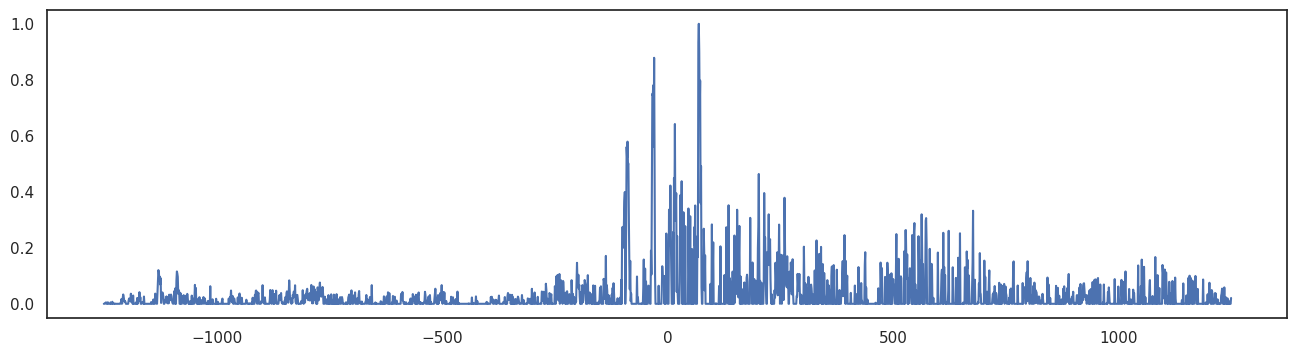

In [6]:
ism_values = (
    (sum_lfc[:, :, exp_id] - sum_lfc[:, :, exp_id].mean(0))
    * hot_encode_sequence(ref_allele)
).max(axis=0)

important_positions = np.where(
    ism_values > MUTATION_THRESHOLD * ism_values.max()
)[0]-1250

print("Most important positions are:")
print(important_positions)

plt.figure(figsize=(16,4))
plt.plot(np.arange(-1250,1250),ism_values/ism_values.max(),scaley=True)

# 7. TF Enrichment Analysis

In [7]:
treatment = gex_metadata.iloc[exp_id].Treatment
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=sum_lfc[:,:,exp_id],
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df,
    motif_dict=pssm_dict_jaspar,
    metadata=csp_metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=MUTATION_THRESHOLD,
    score_threshold=MOTIF_SCORE_THRESHOLD,
    pad=20
)
csv_file_path = f"{gene_results_path}/results_{exp_id}.csv"
results_df.to_csv(csv_file_path,index=False)
print(f"Refer to the csv file at {csv_file_path} to see all mutations positions and TF enrichments")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]
loss_df.head(10)

Refer to the csv file at /s/chromatin/m/nobackup/ahmed/GitRepositries/DeepPlant/results/ISM/AT5G52310/results_2504.csv to see all mutations positions and TF enrichments


,gene,gene_strand,chromosome,tss_relative_position,gene_region,sequence_relative_position,genomic_position,ref,alt,motif,motif_strand,effect,chip_peak_overlap
2,AT5G52310,1,Chr5,-91,promoter,1159,21240626,C,G,MA0971.2.DREB1A,-1,Loss,True
7,AT5G52310,1,Chr5,-91,promoter,1159,21240626,C,G,MA1218.2.DREB1D,-1,Loss,True
11,AT5G52310,1,Chr5,-91,promoter,1159,21240626,C,G,MA1669.2.DREB1B,1,Loss,True
12,AT5G52310,1,Chr5,-91,promoter,1159,21240626,C,G,MA1670.2.DREB1C,1,Loss,True
21,AT5G52310,1,Chr5,-90,promoter,1160,21240627,C,A,MA0971.2.DREB1A,-1,Loss,True
26,AT5G52310,1,Chr5,-90,promoter,1160,21240627,C,A,MA1218.2.DREB1D,-1,Loss,True
30,AT5G52310,1,Chr5,-90,promoter,1160,21240627,C,A,MA1669.2.DREB1B,1,Loss,True
31,AT5G52310,1,Chr5,-90,promoter,1160,21240627,C,A,MA1670.2.DREB1C,1,Loss,True
37,AT5G52310,1,Chr5,-89,promoter,1161,21240628,G,A,MA0971.2.DREB1A,-1,Loss,True
42,AT5G52310,1,Chr5,-89,promoter,1161,21240628,G,A,MA1218.2.DREB1D,-1,Loss,True


# 8. Visualization

Successfully created Zoom_in.bed at: /s/chromatin/m/nobackup/ahmed/GitRepositries/DeepPlant/results/pygenometracks/Zoom_in.bed
Successfully created track.ini at: /s/chromatin/m/nobackup/ahmed/GitRepositries/DeepPlant/results/pygenometracks/track.ini
Successfully created deep_plant_pathtrack__AT5G52310_2504.pdf at: /s/chromatin/m/nobackup/ahmed/GitRepositries/DeepPlant/results/pygenometracks/deep_plant_pathtrack__AT5G52310_2504.pdf
A mutation at position -91 relative to the gene TSS, C -> G causes the loss of the binding site of ['MA0971.2.DREB1A', 'MA1218.2.DREB1D', 'MA1669.2.DREB1B', 'MA1670.2.DREB1C']
A mutation at position -90 relative to the gene TSS, C -> A causes the loss of the binding site of ['MA0971.2.DREB1A', 'MA1218.2.DREB1D', 'MA1669.2.DREB1B', 'MA1670.2.DREB1C']
A mutation at position -89 relative to the gene TSS, G -> A causes the loss of the binding site of ['MA0971.2.DREB1A', 'MA1218.2.DREB1D', 'MA1669.2.DREB1B', 'MA1670.2.DREB1C']
A mutation at position -88 relative t

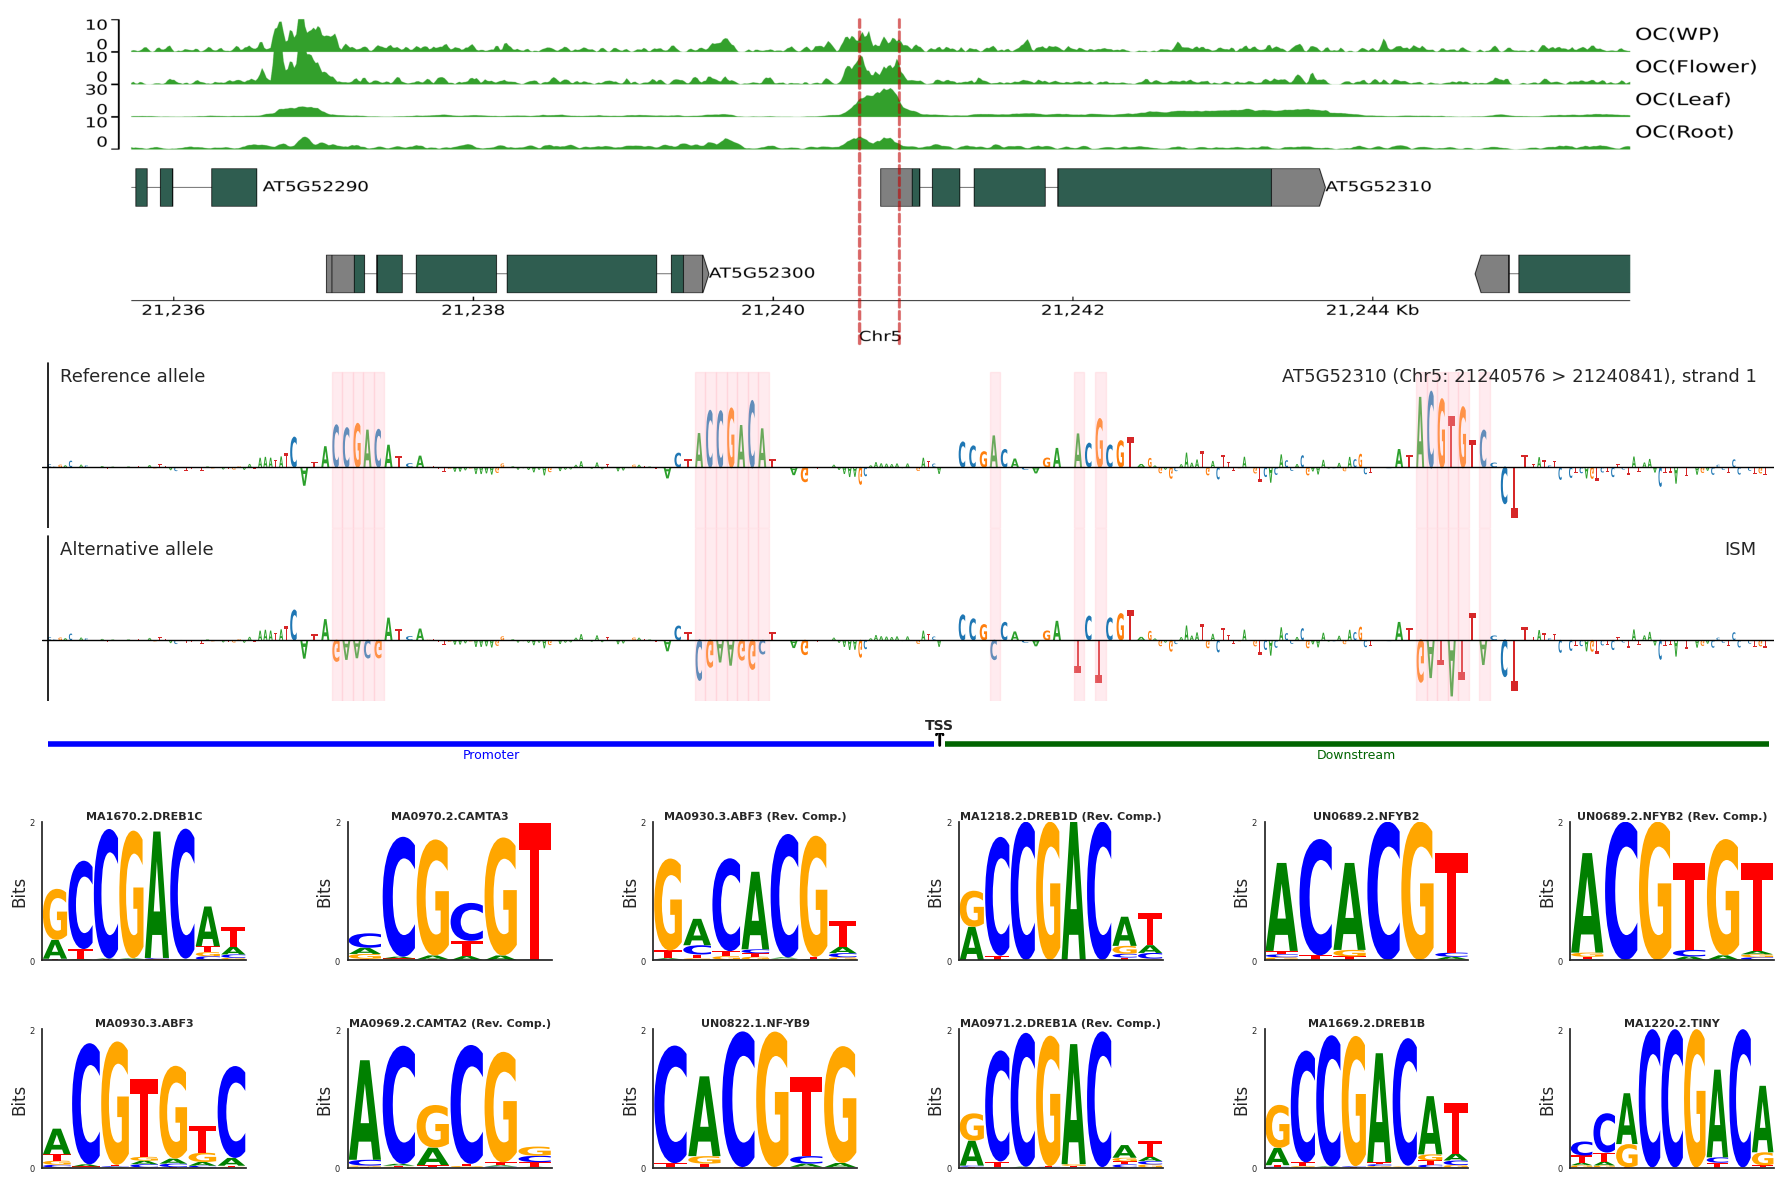

In [8]:
if loss_df.empty:
    print("No significant loss-of-function mutations supported by ChIP-seq data found.")
else:
    start = min(loss_df.sequence_relative_position.values.tolist())-50
    end = max(loss_df.sequence_relative_position.values.tolist())+50
    mutations_bed_path = create_zoom_in_bed(deep_plant_path,chrom,relative_to_genomic_position(start,tss,strand),relative_to_genomic_position(end,tss,strand))
    ini_file_path = create_track_ini(deep_plant_path, mutations_bed_path)
    region = f"Chr{chrom}:{int(tss)-5000}-{int(tss)+5000}"
    output_name = f"deep_plant_pathtrack__{gene}_{exp_id}.pdf"
    figure_path = os.path.join(deep_plant_path,f"results/pygenometracks/{output_name}")
    !pyGenomeTracks --tracks {ini_file_path} --region {region} --outFileName {figure_path} --dpi 500 --trackLabelFraction 0.0 > /dev/null 2>&1
    print(f"Successfully created {output_name} at: {figure_path}")
    plot_ref_alt_ism(
        figure_path=figure_path,
        gene=gene,
        chrom=f"Chr{chrom}",
        sum_lfc=sum_lfc[:,:,exp_id],
        ref_sequence=ref_allele,
        results_df=loss_df,
        start = start,
        end = end,
        tss=tss,
        strand=strand,
        meme_path=meme_path
    )